In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv"
)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

In [4]:
np.random.seed(42)

df["ambient_temperature"] = np.random.normal(
    loc=28,
    scale=5,
    size=len(df)
)

df["factory_load"] = np.random.randint(
    50,
    101,
    size=len(df)
)

df["humidity"] = np.random.randint(
    30,
    90,
    size=len(df)
)

In [5]:
df["temp_gap"] = (
    df["Process temperature [K]"]
    - df["ambient_temperature"]
)

df["load_torque_interaction"] = (
    df["factory_load"]
    * df["Torque [Nm]"]
)

df["humidity_temp_interaction"] = (
    df["humidity"]
    * df["Air temperature [K]"]
)

In [6]:
baseline_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_M",
    "Type_L"
]

X_base = df[baseline_features]

y = df["Machine failure"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

baseline_model = RandomForestClassifier(
    random_state=42
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_preds = baseline_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        baseline_preds
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.90      0.54      0.68        68

    accuracy                           0.98      2000
   macro avg       0.94      0.77      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [8]:
context_features = baseline_features + [
    "ambient_temperature",
    "factory_load",
    "humidity",
    "temp_gap",
    "load_torque_interaction",
    "humidity_temp_interaction"
]

X_context = df[context_features]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_context,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

context_model = RandomForestClassifier(
    random_state=42
)

context_model.fit(
    X_train,
    y_train
)

context_preds = context_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        context_preds
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.85      0.41      0.55        68

    accuracy                           0.98      2000
   macro avg       0.91      0.70      0.77      2000
weighted avg       0.98      0.98      0.97      2000



In [10]:
print("Baseline Model Results")
print(
    classification_report(
        y_test,
        baseline_preds
    )
)

print("\nContextual Model Results")
print(
    classification_report(
        y_test,
        context_preds
    )
)

Baseline Model Results
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.90      0.54      0.68        68

    accuracy                           0.98      2000
   macro avg       0.94      0.77      0.83      2000
weighted avg       0.98      0.98      0.98      2000


Contextual Model Results
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.85      0.41      0.55        68

    accuracy                           0.98      2000
   macro avg       0.91      0.70      0.77      2000
weighted avg       0.98      0.98      0.97      2000



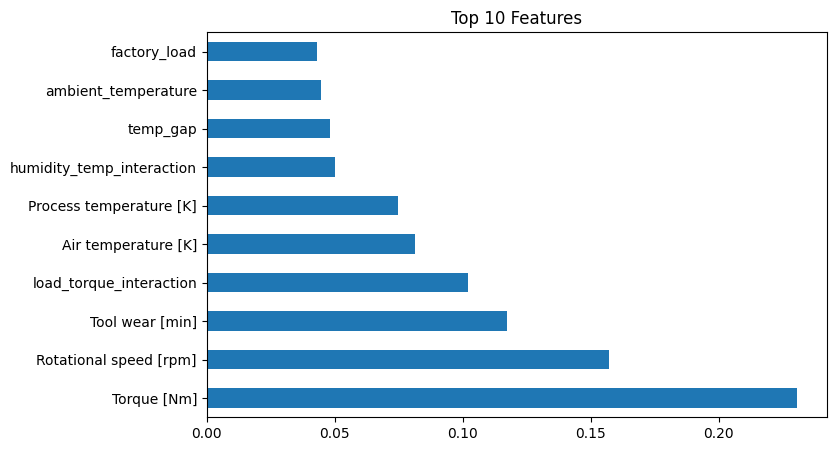

In [11]:
importance = pd.Series(
    context_model.feature_importances_,
    index=X_context.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title(
    "Top 10 Features"
)

plt.show()